In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Take the 2 inputs for start and end years
start_year = int(input("Enter Starting Year: "))
end_year = int(input("Enter Ending Year: "))

In [ ]:
# =======================================
# 1️⃣ Load dataset
# =======================================
df = pd.read_parquet(f"../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_{start_year}-{end_year}.parquet")
print(f"✅ Loaded {len(df)} records with {df.shape[1]} columns")


✅ Loaded 26142 records with 45 columns



--- Missing Values (Top 15) ---
issues_section         74.89
arguments_section      63.79
reasoning_section      59.75
facts_section          22.61
verdict_label           5.50
disposal_nature         2.77
conclusion_section      0.02
case_id                 0.00
sentiment_score         0.00
num_ipc_refs            0.00
has_ipc                 0.00
num_unique_acts         0.00
respondent_mentions     0.00
petitioner_mentions     0.00
ipc_sections            0.00
dtype: float64


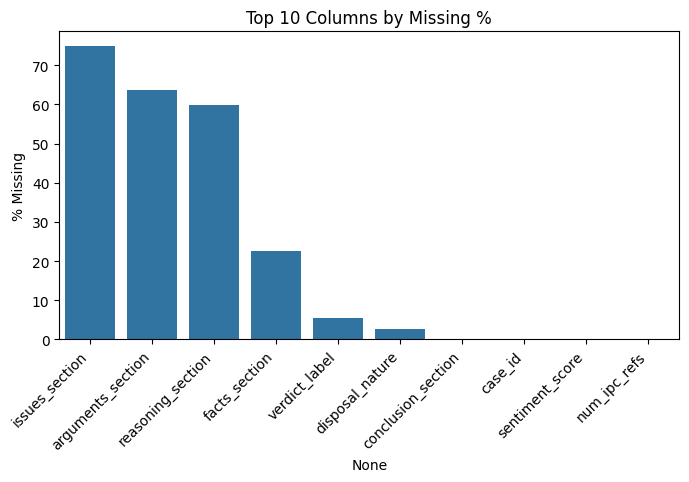

In [4]:
# =======================================
# 2️⃣ Missing value audit
# =======================================
print("\n--- Missing Values (Top 15) ---")
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(15).round(2))

plt.figure(figsize=(8,4))
sns.barplot(x=missing.head(10).index, y=missing.head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Columns by Missing %")
plt.ylabel("% Missing")
plt.show()


--- Verdict Label Distribution ---
verdict_label
1.0    16368
0.0     8336
NaN     1438
Name: count, dtype: int64


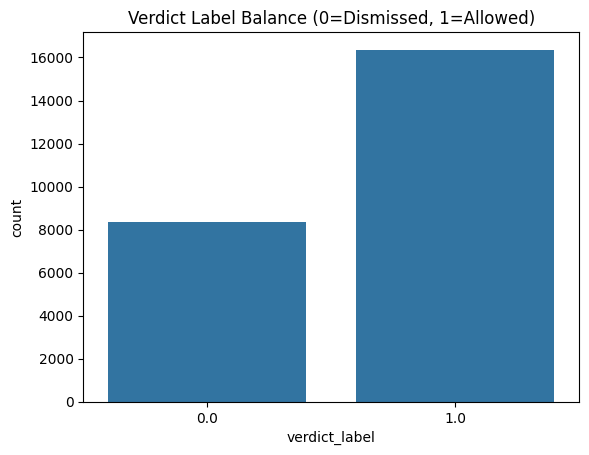

In [5]:
# =======================================
# 3️⃣ Data completeness & label balance
# =======================================
print("\n--- Verdict Label Distribution ---")
print(df['verdict_label'].value_counts(dropna=False))
sns.countplot(x='verdict_label', data=df)
plt.title("Verdict Label Balance (0=Dismissed, 1=Allowed)")
plt.show()


--- Text Length Stats ---
count     26142.00
mean       6188.75
std        9711.92
min           7.00
25%        2442.00
50%        4143.50
75%        6933.50
max      409734.00
Name: text_len, dtype: float64


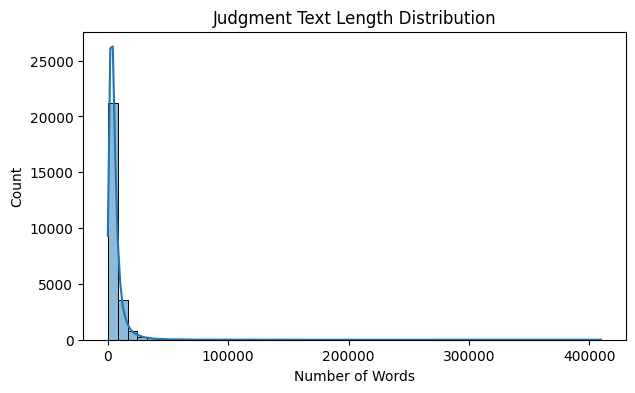

In [6]:
# =======================================
# 4️⃣ Text quality metrics
# =======================================
print("\n--- Text Length Stats ---")
df['text_len'] = df['text'].apply(lambda x: len(str(x).split()))
print(df['text_len'].describe().round(2))

plt.figure(figsize=(7,4))
sns.histplot(df['text_len'], bins=50, kde=True)
plt.title("Judgment Text Length Distribution")
plt.xlabel("Number of Words")
plt.show()

In [7]:
# =======================================
# 5️⃣ Feature richness audit
# =======================================
print("\n--- Bench & Case Type ---")
print("Average bench size:", round(df['bench_size'].mean(), 2))
print("\nCase type distribution:\n", df['case_type'].value_counts(normalize=True).mul(100).round(1))

print("\nHas IPC references:", df['has_ipc'].sum(), "/", len(df))
print("Has Constitution Articles:", df['has_constitution_article'].sum(), "/", len(df))



--- Bench & Case Type ---
Average bench size: 1.19

Case type distribution:
 case_type
Civil             65.6
Criminal          34.1
Constitutional     0.2
Other              0.1
Tax                0.0
Labour             0.0
Name: proportion, dtype: float64

Has IPC references: 5550 / 26142
Has Constitution Articles: 10548 / 26142


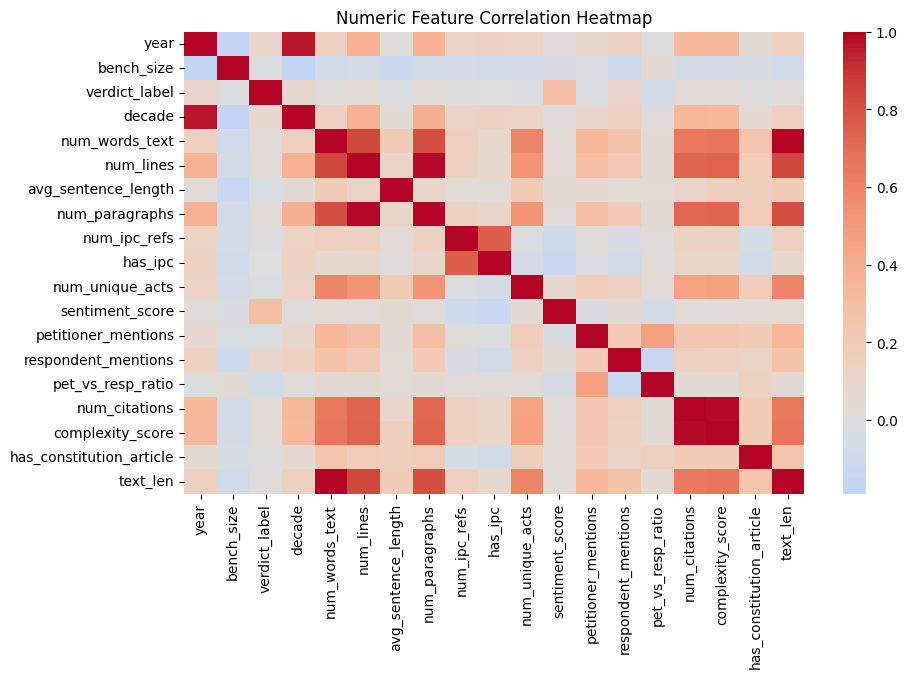

In [8]:
# =======================================
# 6️⃣ Correlation between numeric features
# =======================================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Heatmap")
plt.show()

In [9]:
# =======================================
# 7️⃣ Quick semantic sanity: top frequent Acts & Articles
# =======================================
acts = df['act_names'].explode().dropna().value_counts().head(10)
articles = df['constitution_articles'].explode().dropna().value_counts().head(10)

print("\n--- Top 10 Most Frequent Acts ---\n", acts)
print("\n--- Top 10 Constitution Articles ---\n", articles)


--- Top 10 Most Frequent Acts ---
 act_names
Land Acquisition Act, 1894                1990
Evidence Act, 1872                        1607
Income Tax Act, 1961                      1584
Limitation Act, 1963                      1558
Companies Act, 1956                       1555
Arbitration and Conciliation Act, 1996    1499
Customs Act, 1962                         1113
Industrial Disputes Act, 1947             1101
Motor Vehicles Act, 1988                  1018
Prevention of Corruption Act, 1988         915
Name: count, dtype: int64

--- Top 10 Constitution Articles ---
 constitution_articles
Article 14     10731
Article 226     8732
Article 21      6512
Article 19      6393
Article 32      5964
Article 136     5187
Article 16      5141
Article 142     3664
Article 30      3016
Article 15      2633
Name: count, dtype: int64


In [10]:
# jupyter nbconvert --to python Dataset_Enrichment_Upgraded.ipynb